In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import plotnine as p9
from scipy.stats import zscore

/Users/rk/Documents/Dartmouth/26X/QSS 20/Projects/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/rk/Documents/Dartmouth/26X/QSS 20/Projects/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../charts/delay_change_by_stop.pdf
/Users/rk/Documents/Dartmouth/26X/QSS 20/Projects/.venv/lib/python3.13/site-packages/plotnine/layer.py:358: PlotnineWarning: position_stack : Removed 1 rows containing missing values.
/Users/rk/Documents/Dartmouth/26X/QSS 20/Projects/.venv/lib/python3.13/site-packages/plotnine/layer.py:358: PlotnineWarning: position_stack : Removed 1 rows containing missing values.


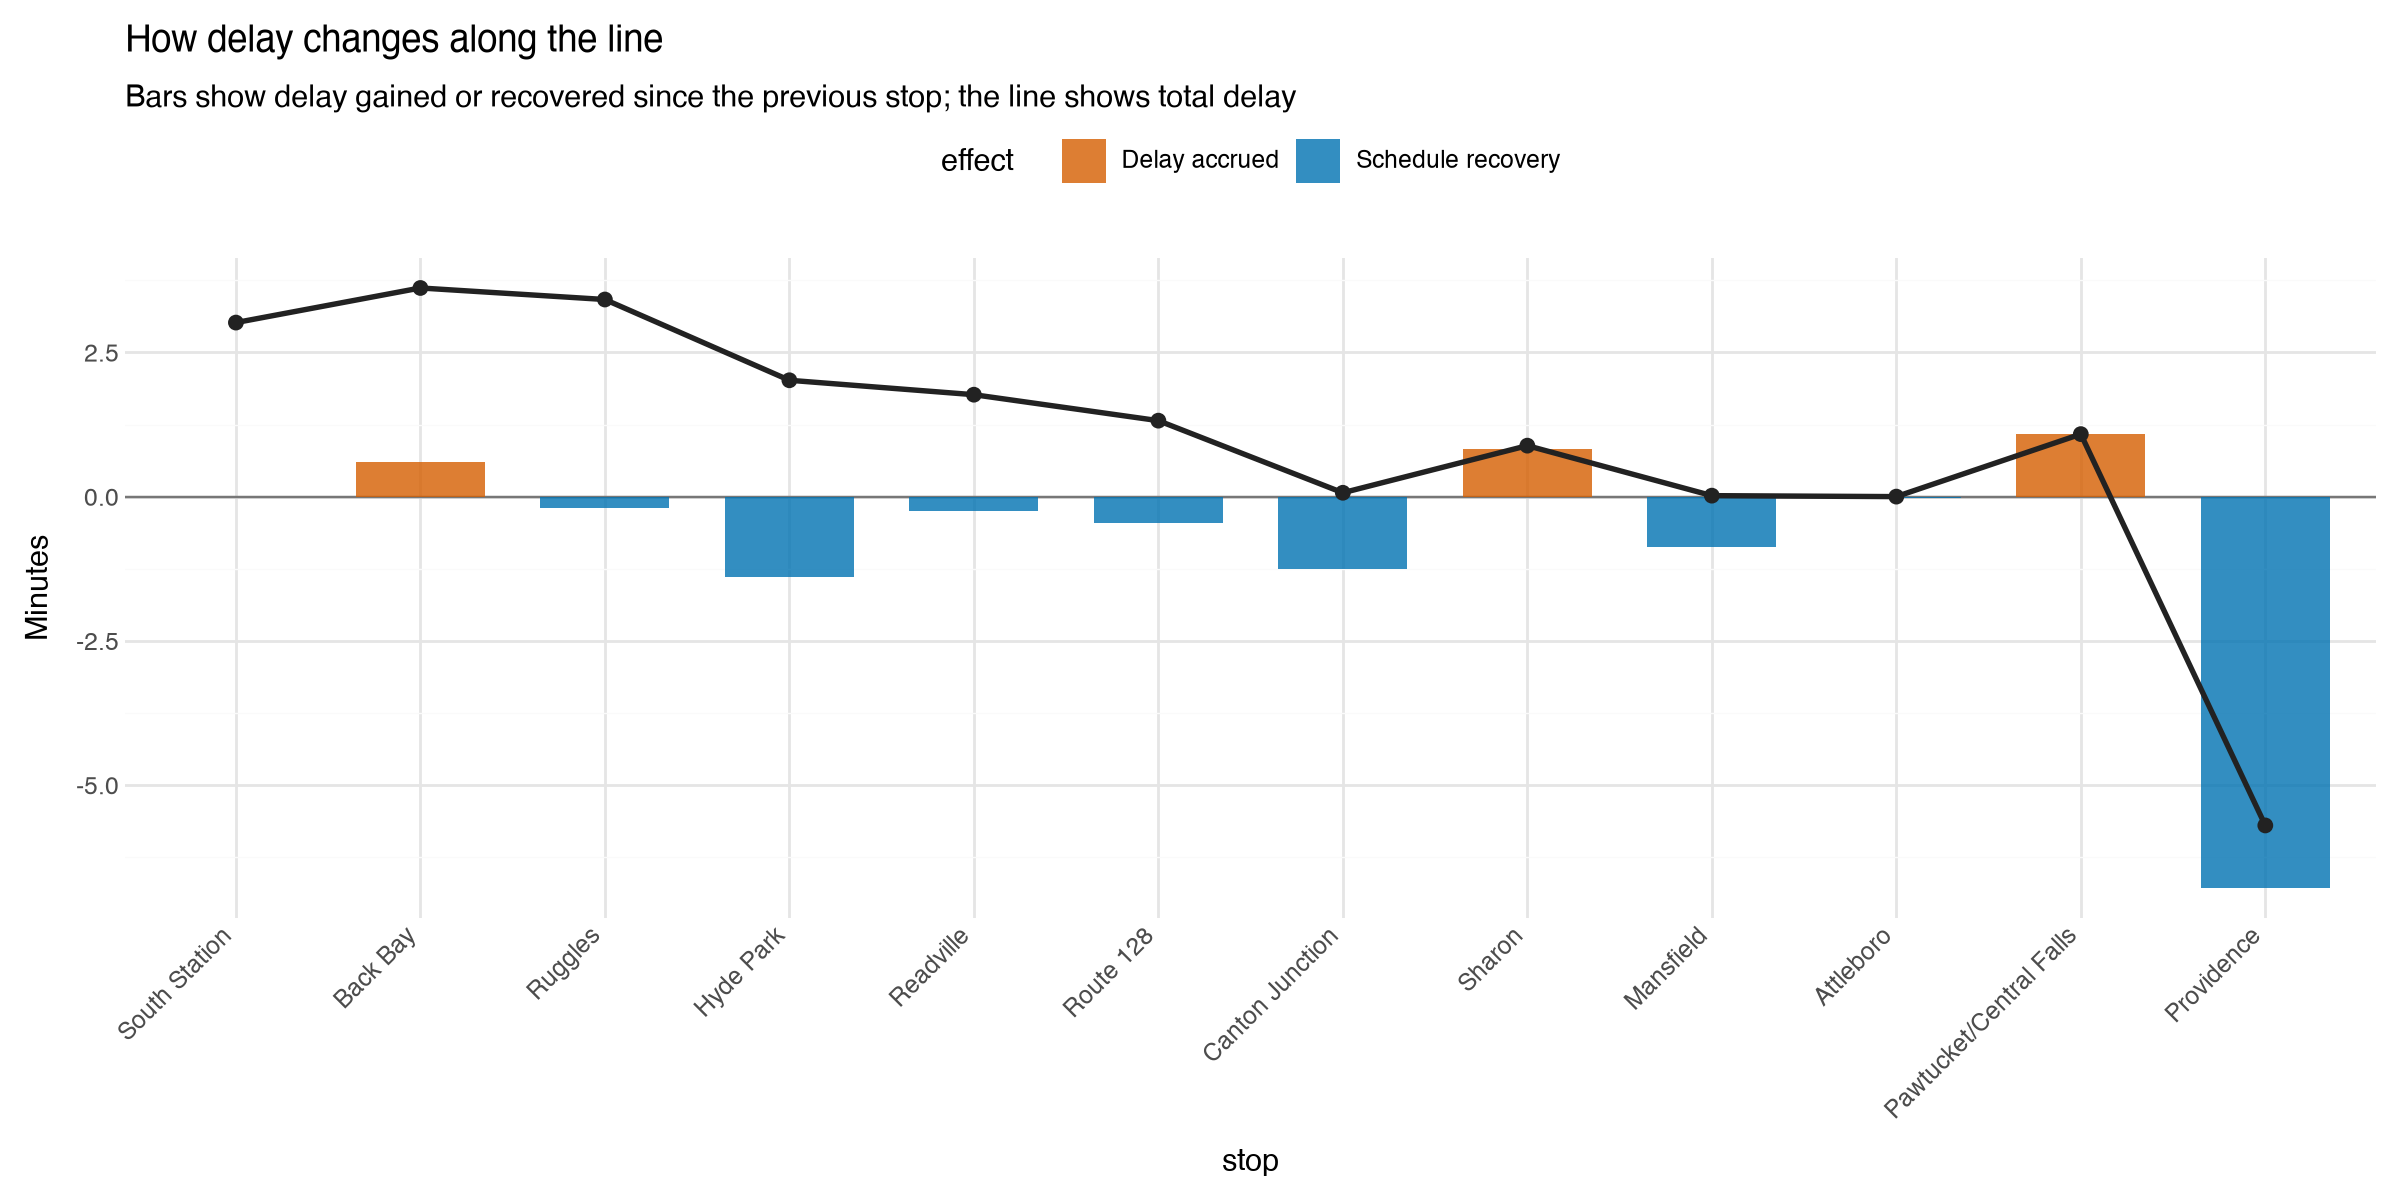

In [ ]:
df = pd.read_csv("../project_data/MBTA 20260801.csv")

time_cols = [
    "departure_time",
    "arrival_time",
    "scheduled_departure_time",
    "scheduled_arrival_time",
]

for col in time_cols:
    df[col] = pd.to_datetime(df[col], unit="s", errors="coerce")

df["time"] = df["departure_time"].combine_first(df["arrival_time"])
df["sched_time"] = df["scheduled_departure_time"].combine_first(
    df["scheduled_arrival_time"]
)

one_train = (
    df.loc[df["train_no"] == 5893]
    .sort_values("sched_time")  # replace if your ordering column differs
    .copy()
)

one_train["delay_min"] = (
    one_train["time"] - one_train["sched_time"]
).dt.total_seconds() / 60

# Change in delay over each segment:
# positive = delay accrued; negative = time recovered against the schedule
one_train["delay_change_min"] = one_train["delay_min"].diff()
one_train["effect"] = np.select(
    [
        one_train["delay_change_min"] > 0,
        one_train["delay_change_min"] < 0,
    ],
    [
        "Delay accrued",
        "Schedule recovery",
    ],
    default="No change",
)

# Preserve the physical stop order on the categorical axis
stop_order = one_train["stop"].drop_duplicates().tolist()
one_train["stop"] = pd.Categorical(
    one_train["stop"],
    categories=stop_order,
    ordered=True,
)

p = (
    p9.ggplot(one_train, p9.aes(x="stop"))
    + p9.geom_hline(yintercept=0, color="#777777", size=0.5)
    + p9.geom_col(
        p9.aes(y="delay_change_min", fill="effect"),
        width=0.7,
        alpha=0.8,
        na_rm=True,
    )
    + p9.geom_line(
        p9.aes(y="delay_min", group=1),
        color="#222222",
        size=1.1,
    )
    + p9.geom_point(
        p9.aes(y="delay_min"),
        color="#222222",
        size=2.2,
    )
    + p9.scale_fill_manual(
        values={
            "Delay accrued": "#D55E00",
            "Schedule recovery": "#0072B2",
            "No change": "#999999",
        }
    )
    + p9.scale_x_discrete(drop=False)
    + p9.labs(
        title="How delay changes along the line",
        subtitle=(
            "Bars show delay gained or recovered since the previous stop; "
            "the line shows total delay"
        ),
        x=None,
        y="Minutes",
        fill=None,
    )
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(12, 6),
        axis_text_x=p9.element_text(rotation=45, ha="right"),
        legend_position="top",
    )
)
p.save("../charts/delay_change_by_stop.pdf")
p.show()

In [ ]:
cr_stations = gpd.read_file("../project_data/MBTA_Commuter_Rail_Stations.geojson")
cr_stations["geometry"] = cr_stations["geometry"].to_crs("EPSG:26986").buffer(8000)
tracts = gpd.read_file("../project_data/tl_2024_25_tract")
tracts["geometry"] = tracts["geometry"].to_crs("EPSG:26986")
cr_tracts = gpd.sjoin(
    tracts, cr_stations[["geometry"]], how="inner", predicate="intersects"
).drop_duplicates(subset="GEOID")

In [ ]:
mhi = (
    pd.read_csv("../project_data/ACSDT5Y2024.B19013-Data.csv")
    .iloc[1:][["GEO_ID", "B19013_001E"]]
    .replace("-", np.nan)
)
mhi["ln_mhi"] = np.log(
    mhi["B19013_001E"].str.replace("+", "").str.replace(",", "").astype(float)
)

ur = (
    pd.read_csv("../project_data/ACSDT5Y2024.B23025-Data.csv")
    .iloc[1:][["GEO_ID", "B23025_003E", "B23025_005E"]]
    .replace("-", np.nan)
)
pvt = (
    pd.read_csv("../project_data/ACSDT5Y2024.B17024-Data.csv")
    .iloc[1:][
        [
            "GEO_ID",
            "B17024_007E",
            "B17024_006E",
            "B17024_005E",
            "B17024_004E",
            "B17024_003E",
            "B17024_002E",
            "B17024_001E",
        ]
    ]
    .replace("-", np.nan)
)

df = mhi.merge(ur, on="GEO_ID", how="inner").merge(pvt, on="GEO_ID", how="inner")

df["unemployment_rate"] = df["B23025_005E"].astype(float) / df["B23025_003E"].astype(
    float
)
df["deep_poverty_rate"] = df["B17024_002E"].astype(float) / df["B17024_001E"].astype(
    float
)

df["below_200pct_poverty"] = df[
    [
        "B17024_002E",
        "B17024_003E",
        "B17024_004E",
        "B17024_005E",
        "B17024_006E",
        "B17024_007E",
    ]
].astype(float).sum(axis=1) / df["B17024_001E"].astype(float)
df[df["GEO_ID"].isin(cr_tracts["GEOIDFQ"].astype(str))]

df["z_ln_mhi"] = zscore(df["ln_mhi"], nan_policy="omit")
df["z_unemployment"] = zscore(df["unemployment_rate"], nan_policy="omit")
df["z_deep_poverty"] = zscore(df["deep_poverty_rate"], nan_policy="omit")
df["z_poverty"] = zscore(df["below_200pct_poverty"], nan_policy="omit")

In [ ]:
df["ses_index"] = (
    0.25 * df["z_ln_mhi"]
    - 0.25 * df["z_unemployment"]
    - 0.25 * df["z_deep_poverty"]
    - 0.25 * df["z_poverty"]
)

In [ ]:
plotting = cr_tracts.merge(df, left_on="GEOIDFQ", right_on="GEO_ID", how="inner")

/Users/rk/Documents/Dartmouth/26X/QSS 20/Projects/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 8 in image.
/Users/rk/Documents/Dartmouth/26X/QSS 20/Projects/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../charts/ses_map.pdf


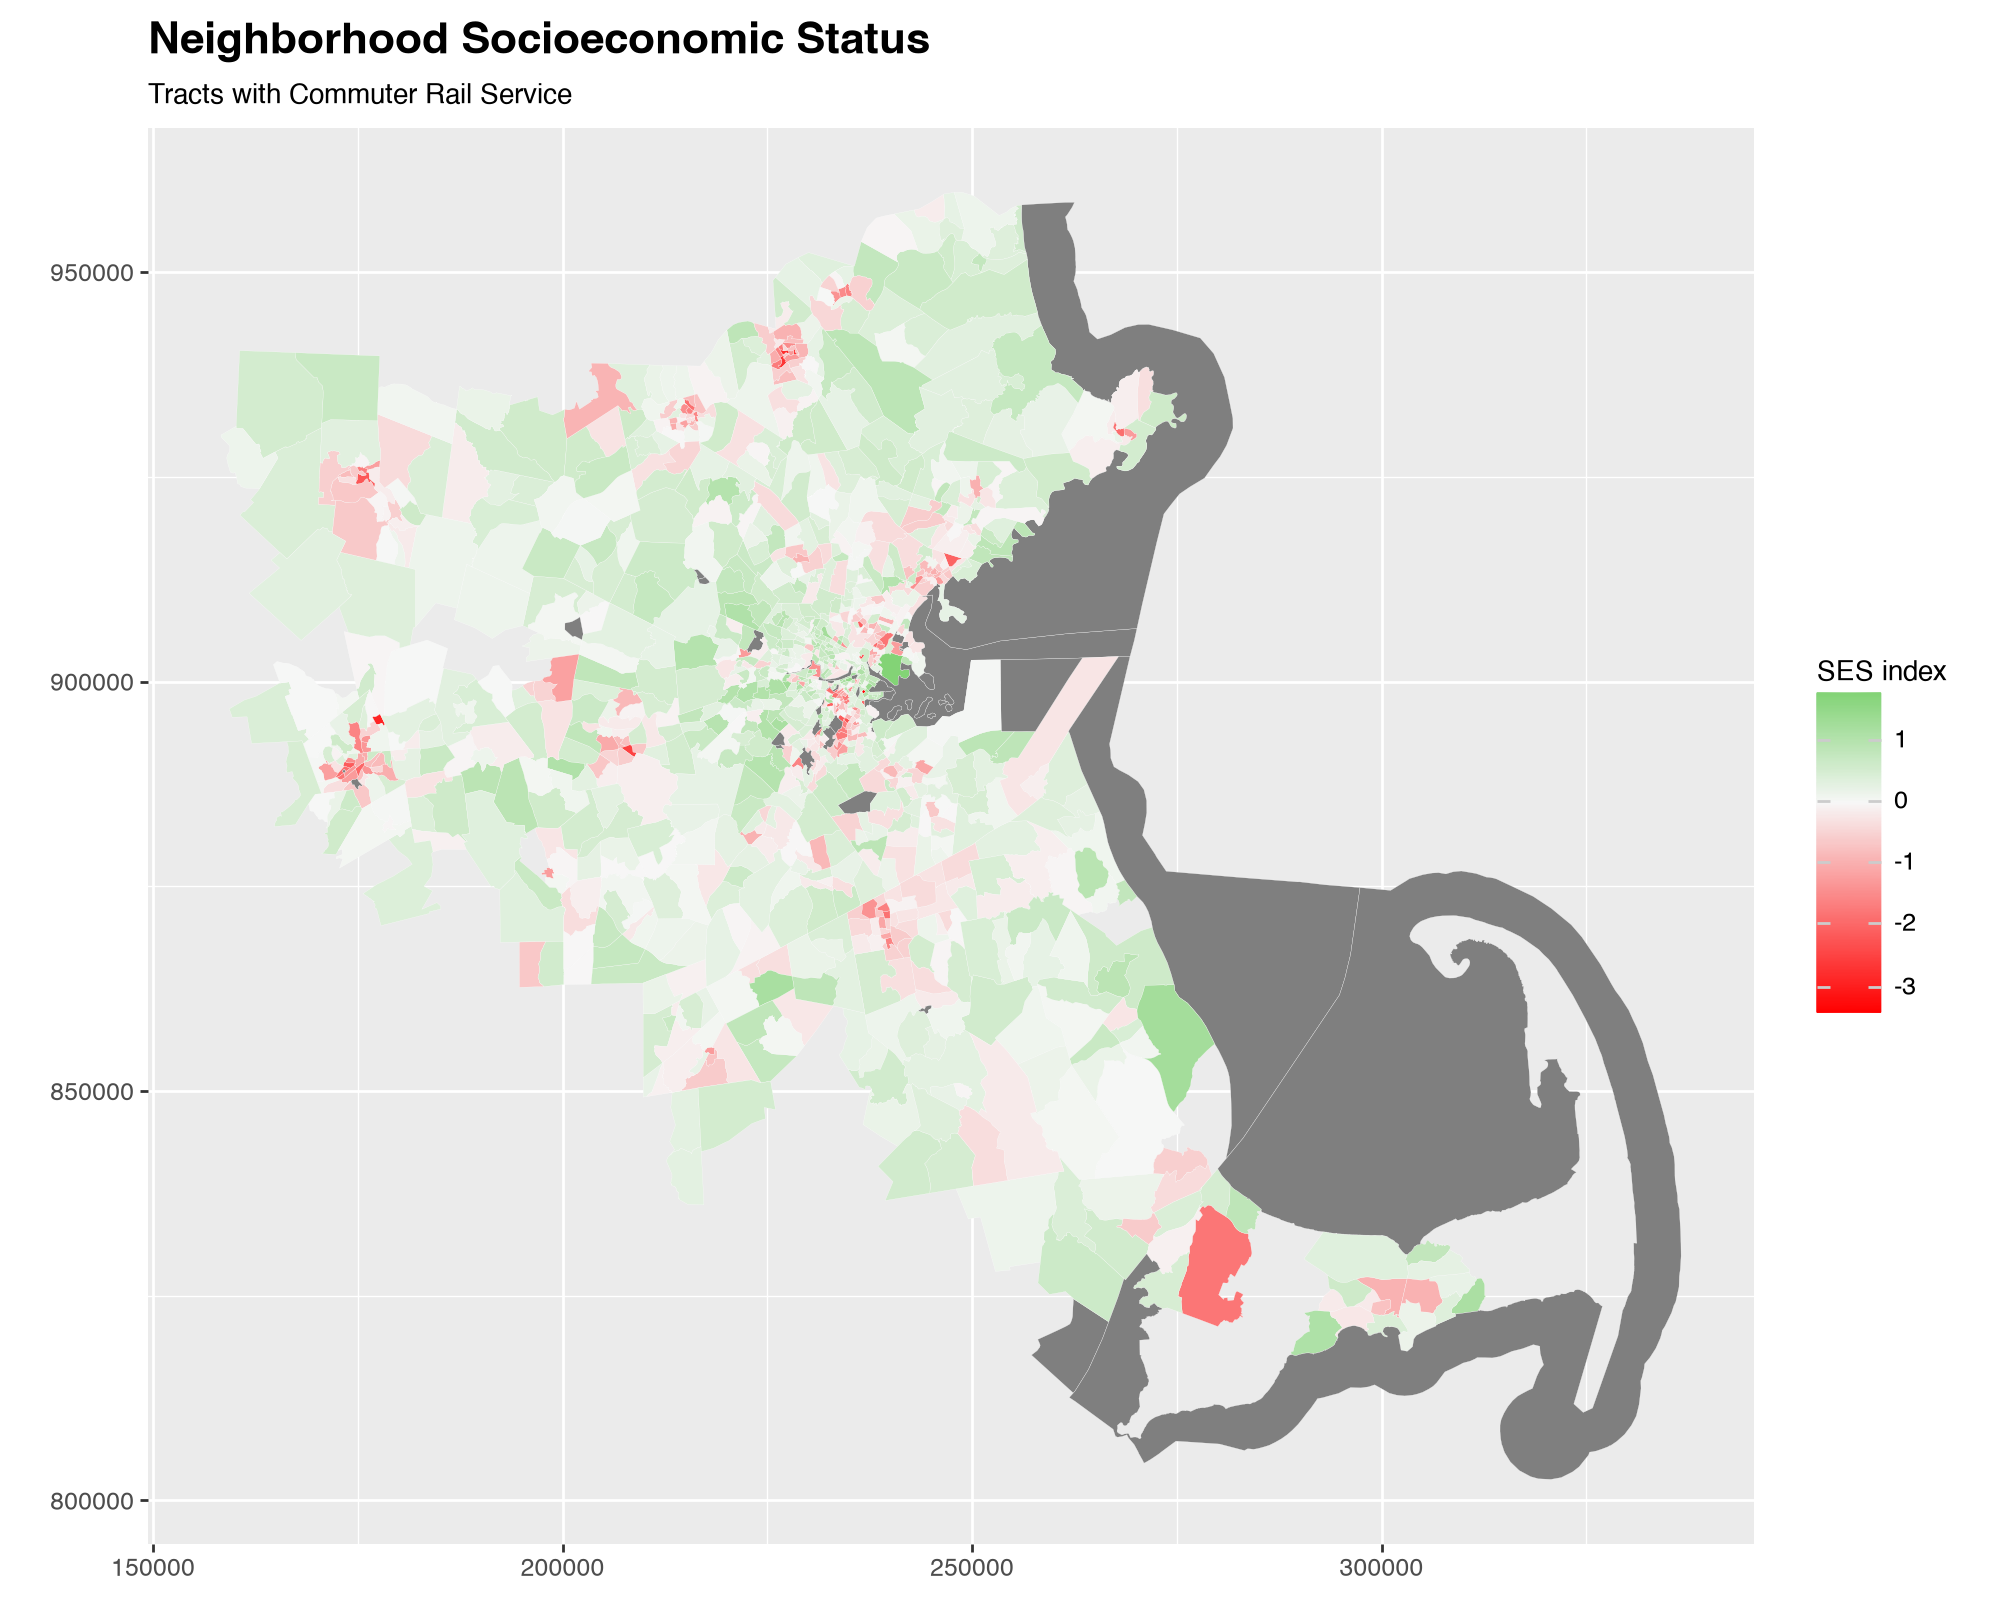

In [112]:
plt = (
    p9.ggplot(plotting)
    + p9.geom_map(p9.aes(fill="ses_index"), color="white", size=0.05)
    + p9.scale_fill_gradient2(
        low="#ff0000",  # low SES
        mid="#f7f7f7",  # average SES
        high="#18b200",  # high SES
        midpoint=0,
        name="SES index",
    )
    + p9.coord_fixed()
    + p9.labs(
        title="Neighborhood Socioeconomic Status",
        subtitle="Tracts with Commuter Rail Service",
    )
    + p9.theme(
        figure_size=(10, 8),
        plot_title=p9.element_text(size=16, weight="bold"),
        plot_subtitle=p9.element_text(size=10),
        legend_title=p9.element_text(size=10),
        legend_text=p9.element_text(size=9),
    )
)
plt.save("../charts/ses_map.pdf")
plt.show()